---
# Evaluate and plot the training results
---

In [1]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from cartopy.feature import LAND, BORDERS
import networkx as nx
import pandas as pd 
from pyproj import Transformer
import numpy as np
import torch
import xarray as xr
from tqdm import tqdm
import include as base
import matplotlib.pyplot as plt

from matplotlib import rcParams
from cycler import cycler
colors = {
    
    'c_darkblue': '#2F7194',
    'c_red': '#ec7070',
    'c_darkgreen': '#48675A',
    'c_lightblue': '#97c3d0',
    'c_lightgreen': '#AFD8BC',
    'c_lightbrown': '#C6BFA2',
    'c_orange': '#EC9F7E',
    'c_yellow': '#F5DDA9',
    'c_darkgrey': '#3D4244',
    'c_pink': '#F8A6A6',
    'c_purple': '#A07CB0',
    'c_lightgrey': '#AFC1B9',
}
rcParams['axes.prop_cycle'] = cycler(color=list(colors.values()))
fs=9
rcParams.update(**{
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb} \usepackage{amsmath}",
    "font.size": fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False
})

In [2]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857")

In [3]:
# Load the lookup table, containing coordinates and ISO codes
lookup_table = pd.read_csv("/Users/thomasgaskin/FAOSTAT_data/lookup_table.csv", index_col=0)

In [29]:
def plot_map(data: xr.DataArray, *, special_countries: list = None, extent: list = None, 
             width_factor: float = 1.0, special_edge_width_factor: float = 5e-5, size_factor: float = 1.0, arrow_dict: dict = {}, 
             min_edge_weight: float = 0.0):
    
    """ Plots a world map"""
    
    # Create an empty nx.network
    nw = nx.DiGraph()
    
    special_countries = [] if special_countries is None else special_countries
    
    export_nodes = data.sum("Destination", skipna=True)
    for country in export_nodes.coords['Source'].data:
        if country == 'Other' or np.isnan(lookup_table.loc[country, 'Latitude']):
            print(f"Missing country {country}")
            continue
        nw.add_node(country, pos=(lookup_table.loc[country, 'Latitude'], lookup_table.loc[country, 'Longitude']), type='Exporter', 
                    export_value=2e-3*export_nodes.sel({"Source": country}).data.item(), import_value=0)
    
    # Add the importers
    import_nodes = data.sum("Source", skipna=True)
    for country in import_nodes.coords['Destination'].data:
        if country == 'Other' or np.isnan(lookup_table.loc[country, 'Latitude']):
            continue
        if country in nw.nodes():
            export_value = nw.nodes[country]["export_value"]
        else:
            export_value = 0
        nw.add_node(country, pos=(lookup_table.loc[country, 'Latitude'], lookup_table.loc[country, 'Longitude']), type='Importer', 
                    import_value=2e-3*import_nodes.sel({"Destination": country}).data.item(), export_value = export_value)
    
    # Add edges
    for country_A in data.coords["Source"].data:
        if country_A == "Other":
            continue
        for country_B in data.coords["Destination"].data:
            if country_B == "Other":
                continue

            # Skip special edges
            skip = False
            for special_country_pair in special_countries:
                if country_A == special_country_pair[0] and country_B == special_country_pair[1]:
                    skip = True
                    break
            if skip:
                continue

            T = data.sel({"Source": country_A, "Destination": country_B})
            if T > 0:
                if np.isnan(lookup_table.loc[country_A, 'Latitude']) or np.isnan(lookup_table.loc[country_B, 'Latitude']):
                    print(f"Missing edge {country_A} -> {country_B}")
                    continue
                nw.add_edge(country_A, country_B, weight=5e-5*T.data.item())

    fig, ax = plt.subplots(figsize=(20, 20), subplot_kw=dict(projection=ccrs.Mercator()))
    land = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m', facecolor=colors['c_lightbrown'])
    sea = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m', facecolor=colors['c_lightblue'], alpha=0.2)
    ax.axis('off')
    ax.add_feature(land, zorder=-2)
    ax.add_feature(sea, zorder=-3)
    ax.add_feature(BORDERS, lw=0.2, zorder=-1)
    
    # Plot the exporters
    pos = dict((k, transformer.transform(*v)) for k, v in nx.get_node_attributes(nw, 'pos').items())
    size = nx.get_node_attributes(nw, 'export_value')
    nx.draw_networkx_nodes(nw, pos, node_size=size_factor * np.array(list(size.values())), ax=ax, node_color=colors["c_darkblue"], alpha=0.5)
    
    # Plot the importers
    size = nx.get_node_attributes(nw, 'import_value')
    nx.draw_networkx_nodes(nw, pos, node_size=size_factor * np.array(list(size.values())), ax=ax, node_color=colors["c_red"], alpha=0.5)

    # Add edges for special countries
    arrow_kwargs = dict(alpha=0.7, connectionstyle='arc3, rad=0.2', arrowsize=10)
    arrow_kwargs.update(**arrow_dict)

    for special_country_pair in special_countries:
        country_1, country_2 = special_country_pair
        nx.draw_networkx_edges(nw, {country_1: pos[country_1], country_2: pos[country_2]}, [special_country_pair], connectionstyle='arc3, rad=0.2', arrowstyle='-',
                           width=special_edge_width_factor*data.sel({"Source": country_1, "Destination": country_2}).data.item(), alpha=0.5)
    edges = [edge for edge in nw.edges if edge not in special_countries]
    _ = nx.draw_networkx_edges(nw, pos, edges, ax=ax, width=np.maximum(min_edge_weight, width_factor * np.array(list(nx.get_edge_attributes(nw, 'weight').values()))), **arrow_kwargs)


    # World
    extent = [-180, 180, -70, 60] if extent is None else extent
    ax.set_extent(extent)
    
    return fig, ax

Missing country Serbia and Montenegro
Missing country Other


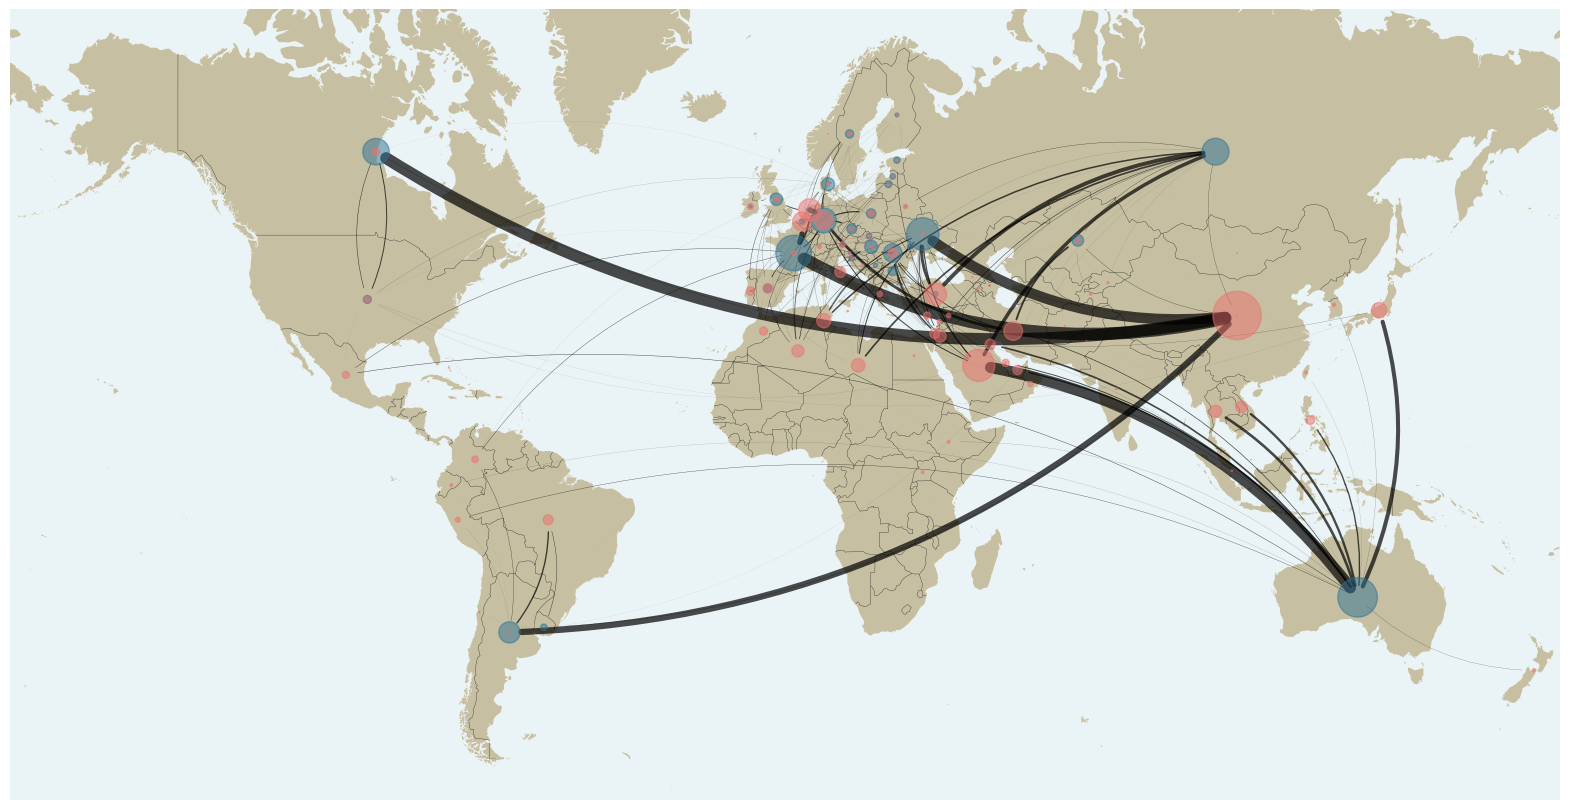

In [33]:
fig, ax = plot_map(xr.open_dataarray(f"/Users/thomasgaskin/FAOSTAT_data/Datasets/Barley_pooled_0.99_2000-2022.nc").sel({"Element": "Quantity, t", "Year": 2021}, drop=True).mean("Reporter", skipna=True), arrow_dict=dict(arrowstyle='-'), extent=[-180, 180, -60, 73], size_factor=0.05, width_factor=5e-2)
fig.savefig("/Users/thomasgaskin/FAOSTAT_data/Barley_2021.png", dpi=300, bbox_inches='tight')

In [167]:
# Commodity
for comm in ['Rice', 'Wheat', 'Bananas', 'Avocados', 'Wine', 'Vegetables', 'Chocolate', 'Cocoa Beans']:
    try:
        plot_map(xr.open_dataarray(f"/Users/thomasgaskin/FAOSTAT_data/{comm}/All_Data_{comm}_Quantity_2000-2022_pooled_0.95.nc").sel({"Year": 2022}).mean("Reporter", skipna=True), country_coords, arrow_dict=dict(arrowstyle='-'), extent=[-180, 180, -60, 73], size_factor=0.5, width_factor=0.5).savefig(f"/Users/thomasgaskin/FAOSTAT_data/{comm}/Plots/{comm}_map.png", dpi=300)
    except: 
        continue

In [ ]:
# Compare the prediction on an edge
def comparison_plot(exp, imp, *, figsize = (20, 5)):
    
    # Create a figure
    fig, axs = plt.subplots(ncols=4, figsize=figsize)
    fig.suptitle(f"{FAO_data.name} trade: {exp} to {imp}", fontsize=18, fontweight='bold')
    
    # Track the handles
    handles = dict((idx, []) for idx in range(len(axs)))
    
    for reporter in ['Exporter', 'Importer']:
        
        # True transport flow (quantity)
        _T = FAO_data.sel({"Reporter": reporter, "Element": "Quantity, t", "Source": exp, "Destination": imp}).dropna("Year")

        # True transport flow (value)
        _V = FAO_data.sel({"Reporter": reporter, "Element": "Value, 1000 USD", "Source": exp, "Destination": imp}).dropna("Year")
        
        # Interpolate the quantity and the value
        _x_t, _y_t = _T.coords["Year"], _T.data 
        _s_t = PchipInterpolator(_x_t, _y_t, extrapolate=True)
        _x_v, _y_v = _V.coords["Year"], _V.data 
        _s_v = PchipInterpolator(_x_v, _y_v, extrapolate=True)
        
        # Plot the true quantity flow
        _d = axs[0].scatter(_T.coords["Year"], _T, label=f"Reporter: {reporter}")
        axs[0].set_title(f"{_T.coords['Element'].data.item()}")
        handles[0].append(_d)
        
        # Plot the true value flow
        _d = axs[1].scatter(_V.coords["Year"], _V, label=f"Reporter: {reporter}")
        axs[1].set_title(f"{_V.coords['Element'].data.item()} (interpolated)")
        
        # Plot the interpolated value flow
        _x_v_interp = np.arange(_x_v.min(), _x_v.max()+1, 1)
        _l = axs[1].plot(_x_v_interp, _s_v(_x_v_interp))
        handles[1].append((_d, _l[0]))
        
        # Plot the value per unit
        _l = axs[2].plot(_x_v_interp, _s_v(_x_v_interp) / _s_t(_x_v_interp))
        _d = axs[2].scatter(_T.coords["Year"], _V / _T)
        axs[2].set_title("Unit cost (USD/kg)")
        handles[2].append((_d, _l[0]))
    
    # Plot the predicted transport flow
    _T_pred = samples["T_pred"].sel({"Source": exp, "Destination": imp})
    _fb = axs[0].fill_between(
        _T_pred.coords["Year"], 
        _T_pred.mean("Sample") - _T_pred.std("Sample"), 
        _T_pred.mean("Sample") + _T_pred.std("Sample"), 
        alpha=0.2, color=colors['c_darkblue']
    )
    _l = axs[0].plot(_T_pred.coords["Year"], _T_pred.mean("Sample"), color=colors['c_darkblue'], linestyle='dotted')
    handles[0].append((_fb, _l[0]))
    
    # Plot the predicted cost
    _C_pred = (samples["C"]).sel({"Source": exp, "Destination": imp})
    _fb = axs[3].fill_between(_C_pred.coords["Year"], 
                        _C_pred.mean("Sample")-_C_pred.std("Sample"), 
                        _C_pred.mean("Sample")+_C_pred.std("Sample"), alpha=0.2, color=colors['c_darkblue'])
    _l = axs[3].plot(_C_pred.coords["Year"], _C_pred.mean("Sample"), label="Predicted C", color=colors['c_darkblue'])
    axs[3].set_title("Predicted cost (unitless)")
    handles[3].append((_fb, _l[0]))
    
    # Add legends
    axs[0].legend(handles=handles[0], labels=['Exporter', 'Importer', 'Prediction'])
    axs[1].legend(handles=handles[1], labels=['Exporter', 'Importer'])
    axs[2].legend(handles=handles[2], labels=['Exporter', 'Importer'])
    axs[3].legend(handles=handles[3], labels=['Cost'])
    
    return fig, axs

In [ ]:
ex, im = "AUS", "CHN"
fig, axs = comparison_plot(ex, im, figsize=(20, 5))
fig.savefig(f"/Users/thomasgaskin/FAOSTAT_data/Barley_{ex}_{im}.png", dpi=300, bbox_inches='tight')

In [ ]:
ex, im = "AUS", "THA"
fig, axs = comparison_plot(ex, im, figsize=(20, 5))
fig.savefig(f"/Users/thomasgaskin/FAOSTAT_data/Barley_{ex}_{im}.png", dpi=300, bbox_inches='tight')

In [ ]:
ex, im = "ARG", "CHN"
fig, axs = comparison_plot(ex, im, figsize=(20, 5))
fig.savefig(f"/Users/thomasgaskin/FAOSTAT_data/Barley_{ex}_{im}.png", dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(7.5, 4))

importer = "China, mainland"
exporter = "Brazil"
for _country in ["Paraguay", "United States of America", "Brazil"]:
    # Plot the cost trajectory for the importer
    _mean = samples["C"].mean("Sample", skipna=True).sel({"Country A": _country, "Country B": importer}, drop=True)
    _std = samples["C"].std("Sample", skipna=True).sel({"Country A": _country, "Country B": importer}, drop=True)

    axs[0].fill_between(_mean.coords['Year'].data, _mean - _std, _mean + _std, alpha=0.4)
    axs[0].plot(_mean.coords['Year'], _mean, label=_country)
axs[0].set_xlim(2000, 2022)
axs[0].legend(title="", ncol=3, loc="upper right", bbox_to_anchor=(0, 1, 1, 0.1), handlelength=0.75, labelspacing=0.3,
              columnspacing=0.8)

for _country in ["China, mainland", "Germany", "France"]:
    # Plot the cost trajectory for the exporter
    _mean = samples["C"].mean("Sample", skipna=True).sel({"Country B": _country, "Country A": exporter}, drop=True)
    _std = samples["C"].std("Sample", skipna=True).sel({"Country B": _country, "Country A": exporter})

    axs[1].fill_between(_mean.coords['Year'].data, _mean - _std, _mean + _std, alpha=0.4)
    axs[1].plot(_mean.coords['Year'], _mean, label=_country)

axs[1].set_xlim(2000, 2022)
axs[1].legend(title="", ncol=3, loc="upper right", bbox_to_anchor=(0, 1, 1, 0.1), handlelength=0.75, labelspacing=0.3,
              columnspacing=0.8)
# plt.savefig("/Users/thomasgaskin/NN_cost_comparison.pdf", bbox_inches='tight', dpi=600)
# Calculate the predicted RPI for the UK
UK_import_mean_cost = (samples["C"].mean("Sample", skipna=True).sel({"Country B": "UK"}, drop=True) * samples["T"].mean(
    "Sample", skipna=True).sel({"Country B": "UK"}, drop=True)).sum("Country A", skipna=True) / samples["T"].mean(
    "Sample", skipna=True).sel({"Country B": "UK"}, drop=True).sum("Country A", skipna=True)

UK_import_mean_cost /= UK_import_mean_cost.sel({"Year": 2000})  # Normalise to 2010 levels

# UK inflation rate, 2010-2022
# UK_inflation_rate = np.array([0.0249, 0.0386, 0.0257, 0.0229, 0.0145, 0.0037, 0.0101, 0.0256, 0.0229, 0.0174, 0.0099, 0.0252, 0.0792])

# Load the RPI
import pandas as pd

RPI_data = pd.read_csv('../../data/IOT/ONS_RPI/Avocados_Pears_Feb_24.csv', index_col=0).astype(
    float).to_xarray().to_array().squeeze(drop=True).sel({"Year": slice(2000, 2022)})

fig, ax = plt.subplots(figsize=(3.75, 2.5))
(UK_import_mean_cost).plot(ax=ax, label='Per-unit import cost')

# Plot the RPI
(RPI_data / RPI_data.isel({"Year": 0})).plot(ax=ax, label='RPI')

# Adjust the RPI for inflation
# RPI_data *= np.array([np.prod(1-UK_inflation_rate[:i]) for i in range(len(UK_inflation_rate+1))])
(RPI_data / RPI_data.isel({"Year": 0})).plot(ax=ax, label='RPI (inflation-adjusted)')
ax.legend()
# plt.savefig("/Users/thomasgaskin/NN_RPI_comparison.pdf", bbox_inches='tight', dpi=600)
# Plot a pie-chart of the import volume and cost
from pie_chart import pie

_data = samples.mean("Sample", skipna=True).sel({"Country B": "China, mainland", "Year": 2022}, drop=True)
_data = _data.where(_data["T"] > 0, drop=True)
plt = pie(
    _data.sortby("C") / _data["C"].mean(),
    x="T",
    y="C",
    hue="C",
    cmap=cm.cmap,
    title="China",
    start_angle=110,
    end_angle=470,
    inner_padding_factor=10,
    subplot_kwargs=dict(figsize=(7, 7))
)
# plt.savefig("/Users/thomasgaskin/NN_UK_pie_chart.pdf", bbox_inches='tight', dpi=600)
_data = samples.mean("Sample", skipna=True).sel({"Country A": "United States of America", "Year": 2022}, drop=True)
_data = _data.where(_data["T"] > 0, drop=True)
plt = pie(
    _data.sortby("C") / _data["C"].mean(),
    x="T",
    y="C",
    hue="C",
    cmap=cm.cmap,
    title="USA",
    outer_padding=1.1,
    start_angle=50,
    inner_padding_factor=5,
    subplot_kwargs=dict(figsize=(7, 7))
)
# plt.savefig("/Users/thomasgaskin/NN_Mexico_pie_chart.pdf", bbox_inches='tight', dpi=600)
# Plot the discrepancy on the trade matrix
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7.5, 2.5), sharey=True, sharex=True)

cm = ColorManager(
    cmap={'from_values': {0: colors['c_lightgreen'], 0.5: colors["c_darkgreen"], 1: colors['c_red']},
          'continuous': True}, norm="LogNorm"
)

ds1 = xr.Dataset(
    dict(Discrepancy=abs(samples.mean("Sample", skipna=True).sel({"Country B": "UK"}, drop=True)["T"] - FAO_data.sel(
        {"Year": slice(2000, None), "Country B": "UK"}, drop=True).mean("Reporter")) / FAO_data.sel(
        {"Year": slice(2000, None), "Country B": "UK"}, drop=True).mean("Reporter"),
         T=samples.mean("Sample", skipna=True).sel({"Country B": "UK"}, drop=True)["T"] /
           samples.mean("Sample", skipna=True).sel({"Country B": "UK"}, drop=True)["T"].sum("Year")
         ))

ds1.fillna(0).plot.scatter(x="Year", y="Discrepancy", markersize="T", hue="T", ax=axs[0], lw=0, alpha=0.5,
                           add_legend=False, cmap=cm.cmap, add_colorbar=False)
ds1["Discrepancy"].mean("Country A", skipna=True).plot.line(ax=axs[0], color=colors["c_red"], label="Mean")
ds1["Discrepancy"].median("Country A", skipna=True).plot.line(ax=axs[0], color=colors["c_darkblue"], label="Median")
axs[0].set_yscale('log')
axs[0].legend(ncol=2)

ds2 = xr.Dataset(
    dict(Discrepancy=abs(
        samples.mean("Sample", skipna=True).sel({"Country A": "Costa Rica"}, drop=True)["T"] - FAO_data.sel(
            {"Year": slice(2000, None), "Country A": "Costa Rica"}, drop=True).mean("Reporter")) / FAO_data.sel(
        {"Year": slice(2000, None), "Country A": "Costa Rica"}, drop=True).mean("Reporter"),
         T=samples.mean("Sample", skipna=True).sel({"Country A": "Costa Rica"}, drop=True)["T"] /
           samples.mean("Sample", skipna=True).sel({"Country A": "Mexico"}, drop=True)["T"].sum("Year")
         ))

ds2.fillna(0).plot.scatter(x="Year", y="Discrepancy", markersize="T", hue="T", ax=axs[1], lw=0, alpha=0.5,
                           add_legend=False, cmap=cm.cmap)
ds2["Discrepancy"].mean("Country B", skipna=True).plot.line(ax=axs[1], color=colors["c_red"], label="Mean")
ds2["Discrepancy"].median("Country B", skipna=True).plot.line(ax=axs[1], color=colors["c_darkblue"], label="Median")
axs[1].set_yscale('log')
axs[1].set_ylabel('')
# plt.savefig("/Users/thomasgaskin/NN_discrepancies.pdf", bbox_inches='tight', dpi=600)
# Import the value
FAO_data_values = xr.open_dataarray(
    "/Users/thomasgaskin/FAOSTAT_data/Soya beans/All_Data_Soya beans_Value_2000-2022_pooled_0.99.nc")
sample_stats = xr.concat(
    [xr.Dataset(dict(mean=(samples["C"]).mean("Sample", skipna=True), std=(samples["C"]).std("Sample", skipna=True))),
     xr.Dataset(
         dict(mean=(FAO_data_values / FAO_data).mean("Reporter"), std=(FAO_data_values / FAO_data).std("Reporter")))],
    dim=pd.Index(['predicted', 'true'], name='type'))

sample_stats /= sample_stats["mean"].isel({"Year": 0})
# Plot a comparison with the
from dantro.plot.funcs.generic import errorbars
from dantro.plot import PlotHelper

hlpr = PlotHelper(
    out_path="",
    helper_defaults={},
    raise_on_error=True,
)
hlpr.setup_figure()

errorbars(data={"data": sample_stats.sel({"Country A": ["Brazil", "Paraguay", "United States of America"],
                                          "Country B": ["China, mainland", "Spain", "Mexico",
                                                        "Netherlands (Kingdom of the)"]})}, hlpr=hlpr, x="Year",
          y='mean', yerr='std', row='Country A', col='Country B', hue="type", use_bands=True, sharey=False,
          add_guide=True)
FAO_data.coords